Addresses issue no [133](https://github.com/open-energy-transition/pypsa-zambia/issues/133)

# Validation of the PyPSA-Zambia generation by hydro powerplants

This notebooks investigates the total energy generation by hydro powerplants by the workflow

Note. The solved network is required as the total generation dispatch of the optimized network is considered. 

## Load python imports

In [25]:
import logging
import os

import pypsa
import pandas as pd
import xarray as xr

logger = logging.getLogger(__name__)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

# change current directory to parent folder
import os
import sys
import pathlib

home = pathlib.Path.home()
if (home / "pypsa-zambia").is_dir():
    os.chdir(home)
sys.path.append(str(home / "pypsa-zambia/scripts"))

# plotting settings
max_node_size = 1.0  # maximum size of a node for plotting purposes [used in plots]

## Load network

Load the PyPSA sovled network

In [3]:
network = os.getcwd() + "/pypsa-zambia/results/networks/elec_s_10_ec_lcopt_Co2L-3h.nc" # change for desired network

n = pypsa.Network(network)

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-3h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Calculate total hydro energy production by powerplants

Total energy production by dams [TWh]

In [4]:
hydroenergy_by_dams = n.storage_units_t.p.clip(lower=0).sum().sum() * n.snapshot_weightings.generators.mean() / 1e6
hydroenergy_by_dams

10.238756709747884

Total energy production by run-of-river [TWh]

In [5]:
ror_gen_index = n.generators[n.generators.carrier == "ror"].index
hydroenergy_by_ror = n.generators_t.p[ror_gen_index].mean().sum() / 1000000 * 8760
hydroenergy_by_ror

0.7932046568054727

Total hydropower energy production [TWh]

In [6]:
tot_hydroenergy = hydroenergy_by_dams + hydroenergy_by_ror
tot_hydroenergy

11.031961366553357

## Calculate Zambia hydro energy production by powerplants

Get Zambian hydropower generators by dam [TWh]

In [7]:
n.storage_units_t.p.columns

Index(['ZM0 1 hydro', 'ZM0 3 hydro', 'ZM0 5 hydro', 'ZM0 7 hydro'], dtype='object', name='StorageUnit')

In [9]:
zambia_hydroenergy_dams = (
    n.storage_units_t.p.mean() / 1000000 * 8760
)
zambia_hydroenergy_dams

StorageUnit
ZM0 1 hydro    2.851671
ZM0 3 hydro    0.105120
ZM0 5 hydro    2.089009
ZM0 7 hydro    5.192956
dtype: float64

Get Zambian hydropower generators by run-of-river [TWh]

In [10]:
ror_generation = n.generators_t.p[ror_gen_index].mean() / 1000000 * 8760
ror_generation

Generator
ZM0 1 ror    0.000000
ZM0 8 ror    0.793205
dtype: float64

## Validation of the data with respect to ERB

The data are compared to ERB report for Hydro generation of 2024:

| Source | Zambia (2024) |
|--------|----------------|
| [ERB 2024](https://drive.google.com/file/d/1B-wlMXfyoqFKrd9EUwkEeGjzU-j0hz69/view?usp=sharing) | 7.47 TWh |

Print PyPSA result

In [12]:
print("| Source    |   Zambia (2013) |")
print(
    "| PyPSA     |      %.2f TWh    |"
    % (tot_hydroenergy)
)

| Source    |   Zambia (2013) |
| PyPSA     |      11.03 TWh    |


## Load Hydro Profile

Load the PyPSA hydro profile.
The hydro profile has been stored in `resources/renewable_profiles/profile_hydro.nc`. 

In [14]:
hydro_path = (
    os.path.realpath("pypsa-zambia")
    + "/resources/renewable_profiles/profile_hydro.nc"
)
hydro = xr.open_dataset(hydro_path)
hydro

<xarray.Dataset> Size: 981kB
Dimensions:  (plant: 13, time: 8760)
Coordinates:
  * plant    (plant) int64 104B 0 1 2 3 5 6 7 8 9 10 11 12 29
  * time     (time) datetime64[ns] 70kB 2013-01-01 ... 2013-12-31T23:00:00
Data variables:
    inflow   (plant, time) float64 911kB ...

### Plot of Hourly inflows

Given the structure of the hydro profiles, we can represent the hourly inflows in one plant: 

In [ ]:
# Determining the plant names
hydro.plant.values

array([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 10, 11, 12, 29])

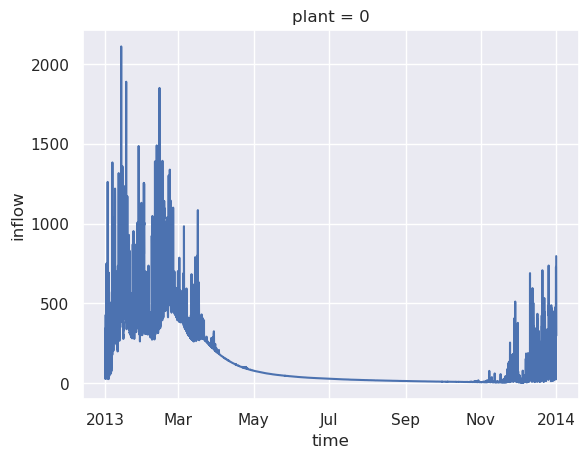

In [22]:
hydro.sel(plant=0).inflow.plot.line(x="time")

Zooming in a specific time period:

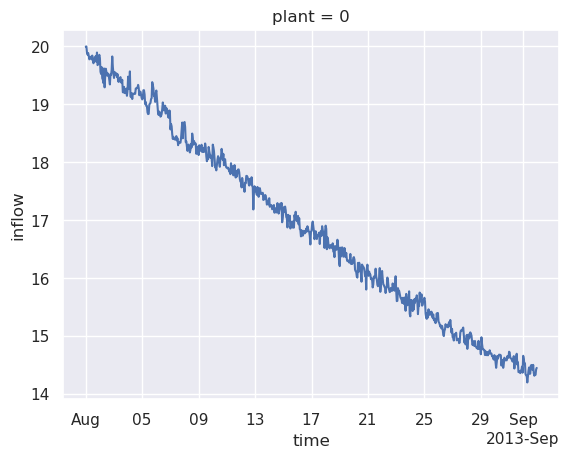

In [24]:
hydro_plant_aug = hydro.sel(plant=0, time=slice("2013-08-01", "2013-09-01"))
hydro_plant_aug.inflow.plot.line(x="time")